# Final Project Notebook

Use the follow cells prompts to complete the final project for the course. Everything you need should be present in this notebook or previous notebooks we've used in class. You can work together as needed.

 - You will need to name your own dataset and use that name throughout
 - There are sections where you need to make changes the code and insert new code this will be noted in the code provided
 - You may get frustrated along the way, this is totally normal, just remember even small changes to the code make a huge difference.

## Question Fork the Repository
i. Include a screenshot of the forked repo in your GitHub account

To fork the repository:
1. Go to https://github.com/NovaVolunteer/ds1001_final
2. Click the "Fork" button in the top right corner
3. The repo will be forked to your GitHub account
4. Take a screenshot of your forked repository

### You should now be able to open your cloned repo in google collab, use the code below.

### It's very helpful to have the variable inspector open while you go through this process. To do so go to tools>command palette>show variable inspector

### It's also helpful to open up the folder tree on the left menu bar. Just click on the folder icon and then the ds1001_final folder. The data is located in the data folder in the processed sub-folder.

In [6]:
!git clone "https://github.com/kevinxue-png/ds1001_final.git"
# This script clones a GitHub repository using Git command line tool.
# Insert the path to your desired repository in place of the URL.

fatal: destination path 'ds1001_final' already exists and is not an empty directory.


## Systems

In [5]:
# Activate the finalproj environment
!source ds1001_final/ds1001_final/finalproj/bin/activate

In [8]:
### You can use this command to list all the packages in your environment
!pip list


Package                                  Version
---------------------------------------- -------------------
absl-py                                  1.4.0
accelerate                               1.13.0
access                                   1.1.10.post3
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.5
aiosignal                                1.4.0
aiosqlite                                0.22.1
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.18.4
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                         

In [37]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

import fairlearn.metrics
from fairlearn.metrics import MetricFrame, true_positive_rate, false_positive_rate, selection_rate, count
#You'll likely need to install the fairlearn packages, if not already installed.
#Are there additional packages to install? (Cross check with the list above to
# ensure all packages are installed)

### Check !pip list again to confirm installations

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import fairlearn.metrics
from fairlearn.metrics import MetricFrame
from fairlearn.metrics import count, true_positive_rate, false_positive_rate, selection_rate, demographic_parity_ratio


## Design: Data prep and exploration

In [38]:
bank = pd.read_csv('ds1001_final/ds1001_final/data/processed/bank_final.csv')

print("Shape:", bank.shape)
display(bank.head())
print(bank.isnull().sum())

Shape: (43628, 13)


,age,job,marital,education,race,default,balance,housing,contact,duration,contactndays,signed up,gender
0,43,self-employed,married,tertiary,white,no,64,no,unknown,230,-1,0,m
1,74,retired,married,primary,white,no,5539,no,cellular,253,181,0,m
2,33,management,married,tertiary,hispanic,no,373,no,cellular,384,-1,0,m
3,37,blue-collar,married,secondary,asian,no,934,no,unknown,258,-1,0,m
4,30,technician,married,tertiary,white,no,1,no,cellular,69,-1,0,f


age             0
job             0
marital         0
education       0
race            0
default         0
balance         0
housing         0
contact         0
duration        0
contactndays    0
signed up       0
gender          0
dtype: int64


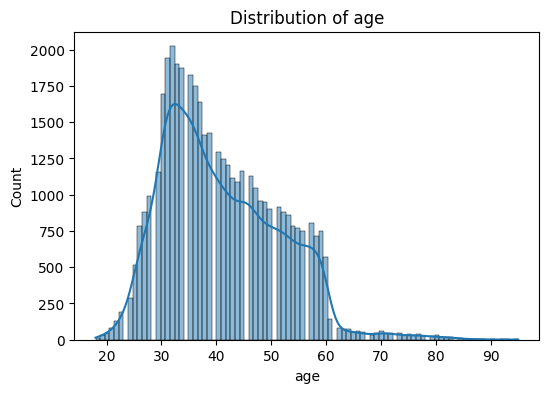

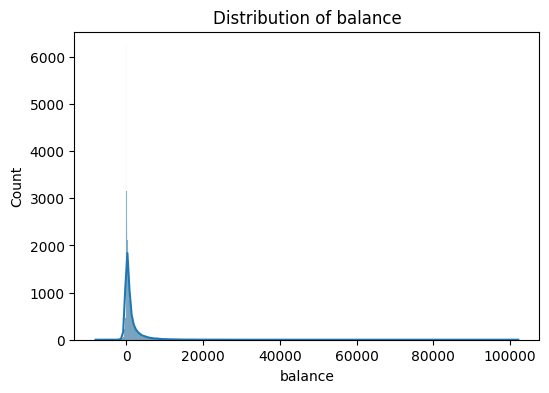

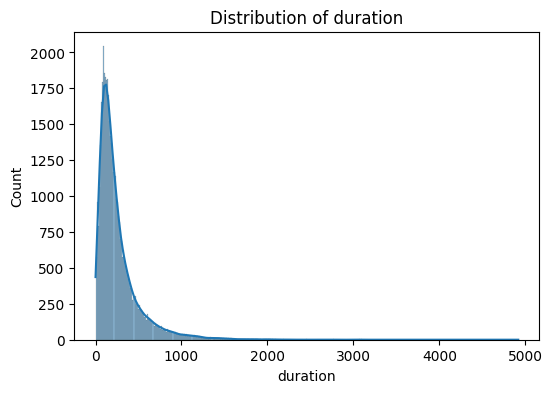

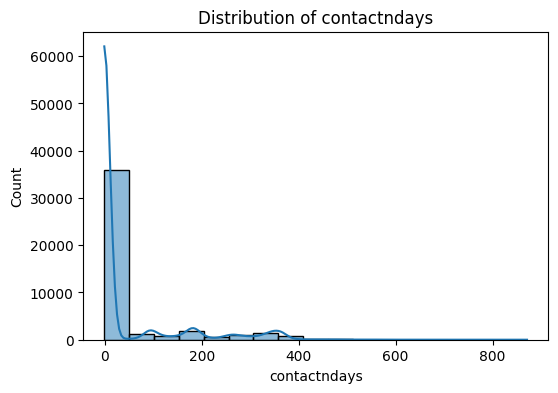

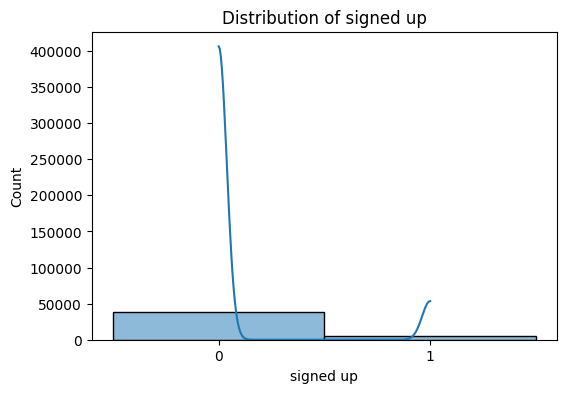

In [64]:
numeric_cols = bank.select_dtypes(include=['number']).columns.tolist()

# ensure target is included if it's numeric or binary encoded
if "signed up" in bank.columns and "signed up" not in numeric_cols:
    numeric_cols.append("signed up")

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(bank[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

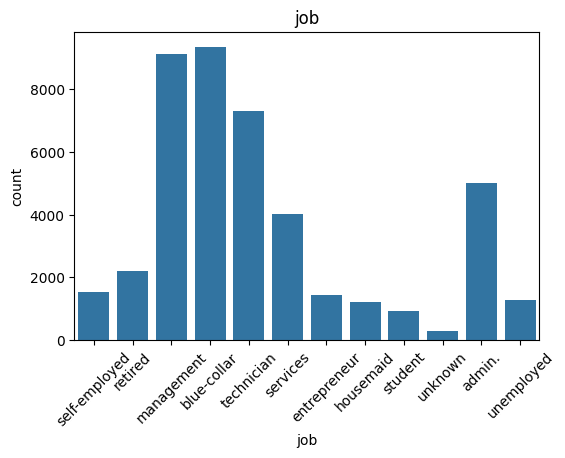

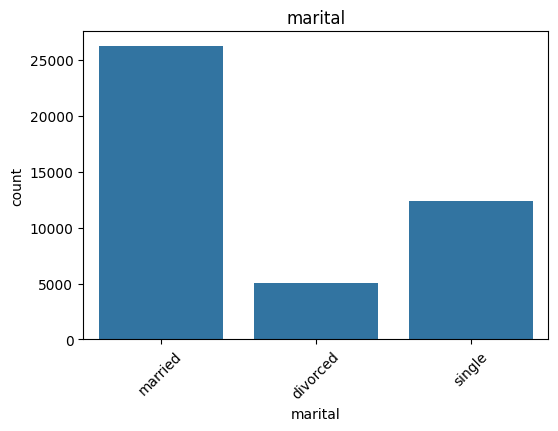

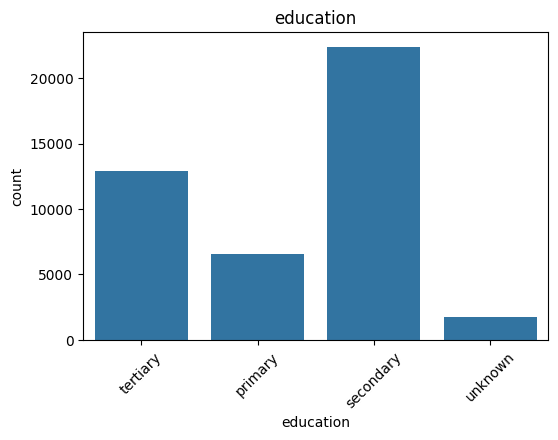

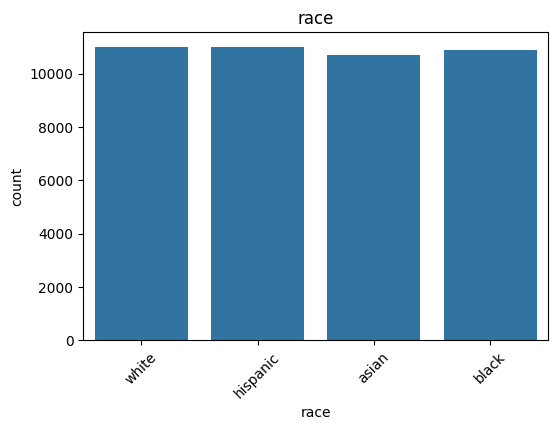

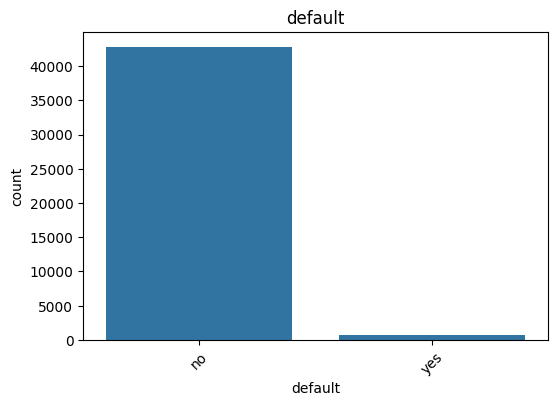

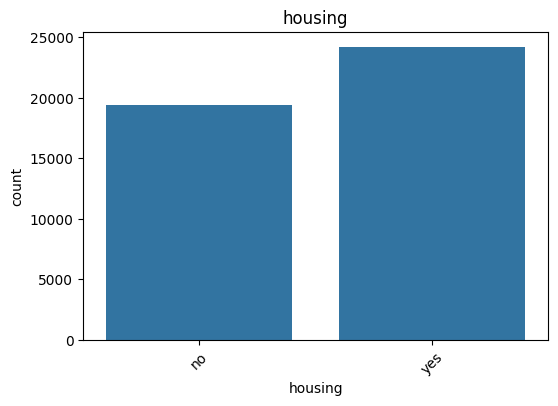

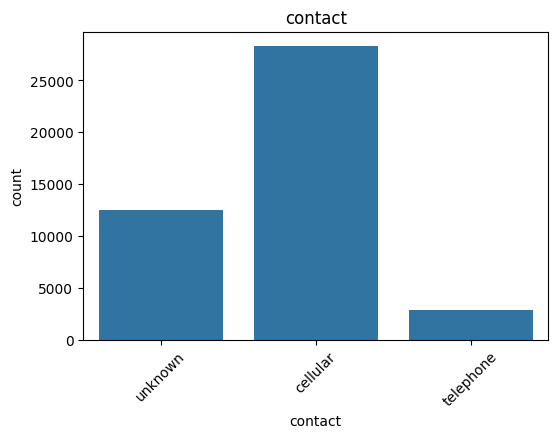

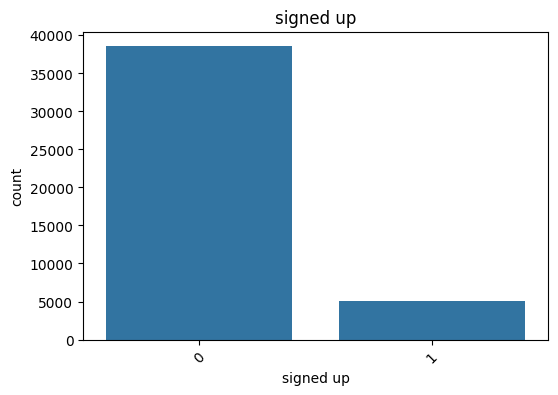

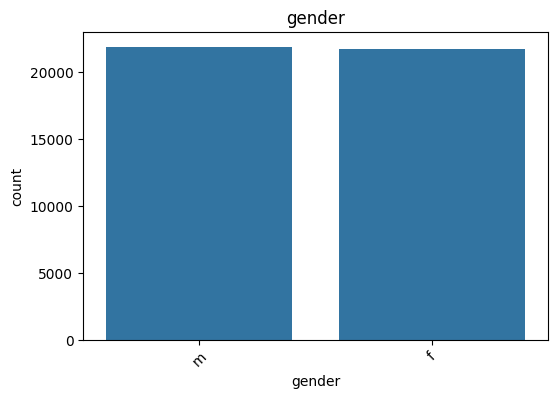

In [61]:
bank["signed up"] = bank["signed up"].astype(str)
categorical_cols = bank.select_dtypes(include=['object']).columns

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=bank[col])
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

In [18]:
num_numeric_columns = bank.select_dtypes(include=['number']).shape[1]
print(num_numeric_columns)

5


In [19]:
# Normalization
scaler = MinMaxScaler()
bank[bank.select_dtypes(include=['number']).columns] = scaler.fit_transform(
    bank.select_dtypes(include=['number'])
)

In [20]:
for col in bank.select_dtypes(include=['object']).columns:
    bank[col] = bank[col].astype('category')

In [21]:
bank = pd.get_dummies(bank, drop_first=True)
bank.shape

(43628, 29)

In [22]:
print(bank.isnull().sum())
bank = bank.dropna()

age                    0
balance                0
duration               0
contactndays           0
signed up              0
job_blue-collar        0
job_entrepreneur       0
job_housemaid          0
job_management         0
job_retired            0
job_self-employed      0
job_services           0
job_student            0
job_technician         0
job_unemployed         0
job_unknown            0
marital_married        0
marital_single         0
education_secondary    0
education_tertiary     0
education_unknown      0
race_black             0
race_hispanic          0
race_white             0
default_yes            0
housing_yes            0
contact_telephone      0
contact_unknown        0
gender_m               0
dtype: int64


In [23]:
# remove missing values if needed
bank = bank.dropna()

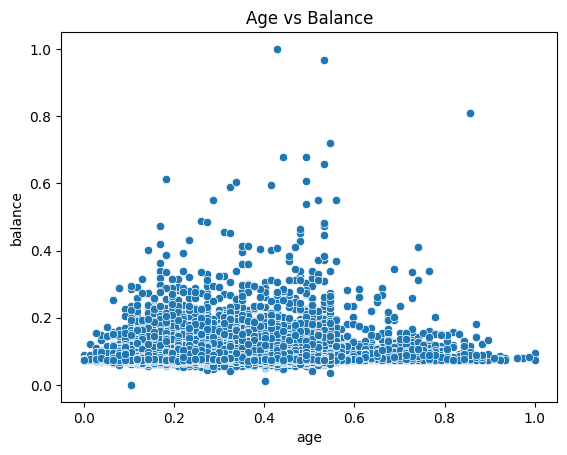

In [24]:
sns.scatterplot(x='age', y='balance', data=bank)
plt.title('Age vs Balance')
plt.show()

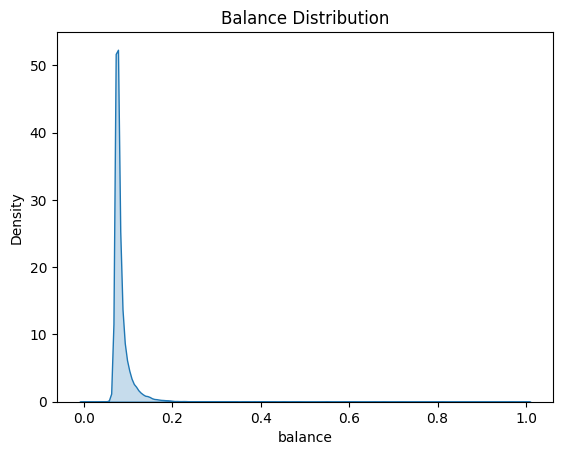

In [25]:
sns.kdeplot(bank['balance'], fill=True)
plt.title('Balance Distribution')
plt.show()

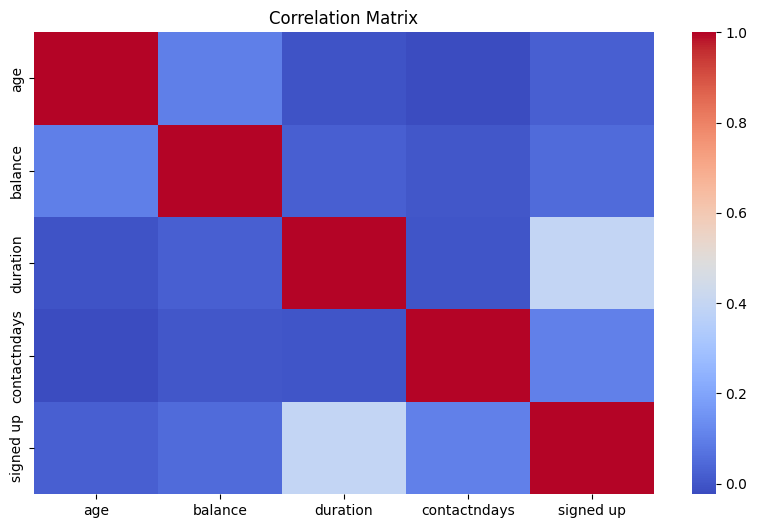

In [56]:
corr = bank.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Matrix")
plt.show()

## Analytics: Build a model and Tune it for best Best Performance

In [40]:
target = bank["signed up"].map({0:0, 1:1, "yes":1, "no":0})
target = bank["signed up"]

In [42]:
features = bank.drop(columns=["signed up"])
features = pd.get_dummies(features, drop_first=True)

imputer = SimpleImputer(strategy="median")
features = pd.DataFrame(imputer.fit_transform(features), columns=features.columns)

scaler = MinMaxScaler()
features = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

In [44]:
k_values = list(range(1, 21, 2))
results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)

    results.append((k, acc))

results_df = pd.DataFrame(results, columns=["k", "accuracy"])
results_df

,k,accuracy
0,1,0.852739
1,3,0.873023
2,5,0.877951
3,7,0.878982
4,9,0.880587
5,11,0.880816
6,13,0.882420
7,15,0.882420
8,17,0.882535
9,19,0.882535


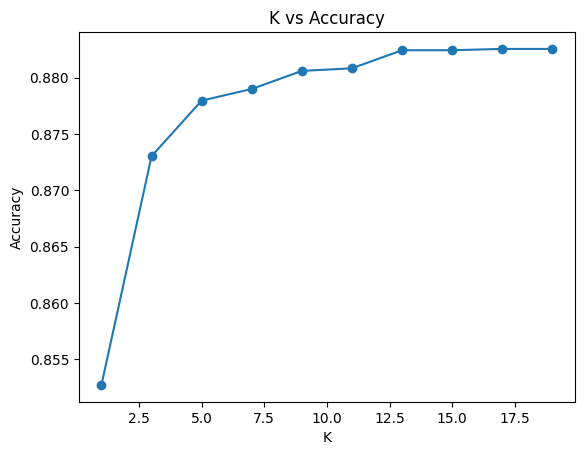

In [45]:
plt.plot(results_df["k"], results_df["accuracy"], marker="o")
plt.title("K vs Accuracy")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

In [46]:
best_k = results_df.loc[results_df["accuracy"].idxmax(), "k"]

final_model = KNeighborsClassifier(n_neighbors=int(best_k))
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

print("Best k:", best_k)

Best k: 17


## Value: Evaluation and Protected Classes

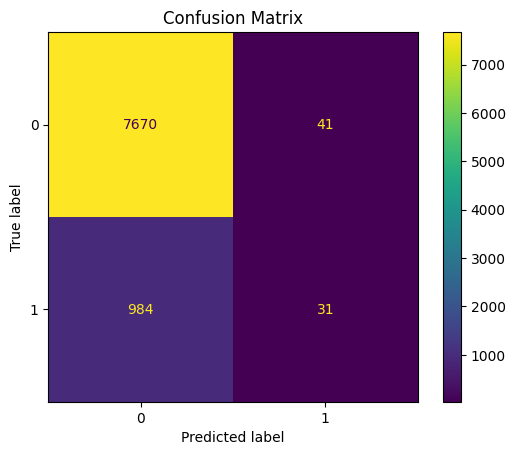

              precision    recall  f1-score   support

           0       0.89      0.99      0.94      7711
           1       0.43      0.03      0.06      1015

    accuracy                           0.88      8726
   macro avg       0.66      0.51      0.50      8726
weighted avg       0.83      0.88      0.83      8726



In [47]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))

In [51]:
X_test_index = X_test.index

race = bank.loc[X_test_index, "race"]
gender = bank.loc[X_test_index, "gender"]

In [53]:
mf_race = MetricFrame(
    metrics={
        "tpr": true_positive_rate,
        "fpr": false_positive_rate,
        "selection_rate": selection_rate
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=race
)

mf_race.by_group

,tpr,fpr,selection_rate
race,,,
asian,0.031008,0.003553,0.006732
black,0.027451,0.005297,0.007933
hispanic,0.030075,0.008924,0.011515
white,0.033898,0.003593,0.006868


In [52]:
mf_gender = MetricFrame(
    metrics={
        "tpr": true_positive_rate,
        "fpr": false_positive_rate,
        "selection_rate": selection_rate
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=gender
)

mf_gender.by_group

,tpr,fpr,selection_rate
gender,,,
f,0.022822,0.004965,0.006962
m,0.037523,0.005664,0.009509


In [55]:
# Derived fairness metrics. Be sure you understand the scale and meaning of these. Here we are calculating the
# two fairness ratios using the gender_m feature, which is bi-variate. What do the results show, is the model more or
# less fair with this grouping?

dpr_gender = fairlearn.metrics.demographic_parity_ratio(y_test, y_pred, sensitive_features=X_test['gender_m'])
print("Demographic Parity ratio:\t", dpr_gender)

eodds_gender = fairlearn.metrics.equalized_odds_ratio(y_test, y_pred, sensitive_features=X_test['gender_m'])
print("Equalized Odds ratio:\t\t", eodds_gender)

Demographic Parity ratio:	 0.7321884427941517
Equalized Odds ratio:		 0.6081950207468879


In [54]:
from fairlearn.metrics import demographic_parity_ratio, equalized_odds_ratio

print("Gender DPR:", demographic_parity_ratio(y_test, y_pred, sensitive_features=gender))
print("Gender EOR:", equalized_odds_ratio(y_test, y_pred, sensitive_features=gender))

print("Race DPR:", demographic_parity_ratio(y_test, y_pred, sensitive_features=race))
print("Race EOR:", equalized_odds_ratio(y_test, y_pred, sensitive_features=race))

Gender DPR: 0.7321884427941517
Gender EOR: 0.6081950207468879
Race DPR: 0.5846499102333932
Race EOR: 0.3981785607644073


In [ ]:
#Optional code to add, commit, and push changes to your GitHub repository
!git add .
!git commit -m "Insert Message Here" # This will commit your changes to git.
!git push # This will push your changes to back to your remote repository on GitHub.